# Reinforcement Learning con Q-Learning

## ¿Qué es el Reinforcement Learning?

**Reinforcement Learning (RL)** es un tipo de machine learning donde un Agent aprende a tomar decisiones interactuando con un Environment:

1. **Agent**: El aprendiz (nuestro algoritmo Q-learning)
2. **Environment**: El mundo (cuadrícula FrozenLake)
3. **State**: Situación actual (posición en la cuadrícula)
4. **Action**: Lo que el Agent puede hacer (moverse IZQUIERDA/ABAJO/DERECHA/ARRIBA)
5. **Reward**: Retroalimentación del Environment (+1 para el Goal, 0 en caso contrario)
6. **Policy**: Estrategia para elegir Actions

## Descripción General de Q-Learning

**Q-Learning** es un algoritmo de Reinforcement Learning *sin modelo (model-free)*:
- **Sin modelo**: No necesitamos conocer la dinámica del Environment de antemano
- **Off-policy**: Podemos aprender la Policy óptima mientras seguimos una Policy diferente (exploración)
- **Basado en valores**: Aprendemos el valor de los pares State-Action


## El Proceso

### Paso 1: Inicializar
- Crear una Q-table (states × actions) llena de ceros
- El Agent no sabe nada al principio

### Paso 2: Bucle de Entrenamiento
Para muchos episodios:
1. Comenzar en el State inicial
2. Elegir Action usando la **Policy Epsilon-Greedy** (explorar vs explotar)
3. Tomar Action, observar Reward y nuevo State
4. **Actualizar Q-value** usando: Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]
5. Repetir hasta que el episodio termine
6. Reducir gradualmente la exploración (decaimiento de epsilon)

### Paso 3: Evaluación
- Probar la Policy aprendida usando la **Policy greedy** (sin exploración)
- Medir el rendimiento (Reward promedio)

### Paso 4: Usar el Agent entrenado
- Desplegar el Agent usando la Q-table aprendida
- Siempre elegir la Action con el Q-value más alto para cada State

## Idea Clave

¡El Agent aprende mediante **ensayo y error**, acumulando gradualmente conocimiento sobre qué Actions llevan al Goal y cuáles llevan al fracaso. La Q-table se convierte en una "hoja de trucos" para navegar el Environment de forma óptima!

Usamos el Environment Frozen Lake como ejemplo básico de un Environment de Gymnasium.

https://gymnasium.farama.org/environments/toy_text/frozen_lake/

Frozen Lake consiste en cruzar un lago congelado desde el inicio hasta el Goal sin caer en ningún agujero caminando sobre el lago helado. El jugador puede no moverse siempre en la dirección deseada debido a la naturaleza resbaladiza del lago congelado.

El juego comienza con el jugador en la posición [0,0] del mundo de cuadrícula del lago congelado, con el Goal ubicado en el extremo opuesto del mundo, por ejemplo [3,3] para el Environment de 4x4.

Los agujeros en el hielo se distribuyen en ubicaciones fijas cuando se usa un mapa predeterminado o en ubicaciones aleatorias cuando se genera un mapa aleatorio. Los mundos generados aleatoriamente siempre tendrán un camino hacia el Goal.

El jugador realiza movimientos hasta alcanzar el Goal o caer en un agujero.

El lago puede ser resbaladizo (a menos que se deshabilite), por lo que el jugador puede moverse en dirección perpendicular a la dirección deseada en ocasiones.

In [ ]:
import numpy as np
import random

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make(
    'FrozenLake-v1',
    desc=None,
    map_name="4x4",
    is_slippery=False,  # Environment determinístico
    render_mode="rgb_array"  # Renderizado en notebook
)

env.reset() # Reiniciar el Environment

def show_env(env):
    '''Renderizar y mostrar el Environment en el notebook.'''
    img = env.render()
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_env(env)

El Environment fue creado con el mapa predeterminado:

```python
desc=["SFFF","FHFH","FFFH","HFFG"]
```

<table border="1">
        <tr><td>S</td><td>F</td><td>F</td><td>F</td></tr>
        <tr><td>F</td><td>H</td><td>F</td><td>H</td></tr>
        <tr><td>F</td><td>F</td><td>F</td><td>H</td></tr>
        <tr><td>H</td><td>F</td><td>F</td><td>G</td></tr>
</table>
<p><b>S</b>=Inicio, <b>F</b>=Congelado, <b>H</b>=Agujero, <b>G</b>=Goal</p>

In [ ]:
print("Espacio de Observación", env.observation_space)

Con `Observation Space Shape Discrete(16)` vemos que la observación es un valor que representa la **posición actual del Agent como fila_actual * nfilas + columna_actual (donde tanto la fila como la columna comienzan en 0)**.

Por ejemplo, la posición del Goal en el mapa 4x4 se puede calcular así: 3 * 4 + 3 = 15. El número de observaciones posibles depende del tamaño del mapa. **Por ejemplo, el mapa 4x4 tiene 16 observaciones posibles.**


<table border="1">
  <tr><td>0</td><td>1</td><td>2</td><td>3</td></tr>
  <tr><td>4</td><td>5</td><td>6</td><td>7</td></tr>
  <tr><td>8</td><td>9</td><td>10</td><td>11</td></tr>
  <tr><td>12</td><td>13</td><td>14</td><td>15</td></tr>
</table>


In [ ]:
print("Forma del Espacio de Actions", env.action_space)

El espacio de Actions (el conjunto de Actions posibles que puede tomar el Agent) es discreto con 4 Actions disponibles 🎮:
- 0: IR A LA IZQUIERDA
- 1: IR ABAJO
- 2: IR A LA DERECHA
- 3: IR ARRIBA

Función de Reward 💰:
- Alcanzar el Goal: +1
- Alcanzar un agujero: 0
- Alcanzar casilla congelada: 0

In [ ]:
from IPython.display import clear_output
import time

for episode in range(10):
    state, info = env.reset()
    done = False
    step = 0
    print(f"Episodio {episode + 1} iniciando...")

    # Mostrar State inicial
    clear_output(wait=True)
    show_env(env)
    print(f"Episodio {episode + 1}, Paso {step}: State {state}")
    time.sleep(0.1)

    while not done:
        action = env.action_space.sample()  # Action aleatoria
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step += 1

        # Limpiar y mostrar Environment actualizado
        clear_output(wait=True)
        show_env(env)
        print(f"Episodio {episode + 1}, Paso {step}: State {state} --Action {action}--> Siguiente State {next_state}, Reward: {reward}")

        state = next_state
        time.sleep(0.05)  # Pausa entre frames

    print(f"Episodio {episode + 1} finalizado en {step} pasos.\n")
    time.sleep(1)  # Pausa entre episodios

In [ ]:
state_space = env.observation_space.n
print("Hay ", state_space, " States posibles")

action_space = env.action_space.n
print("Hay ", action_space, " Actions posibles")

In [ ]:
# Creamos nuestra Qtable de tamaño (state_space, action_space) e inicializamos cada valor en 0 usando np.zeros
def initialize_q_table(state_space, action_space):
    Qtable = np.zeros((state_space, action_space))
    return Qtable


Qtable_frozenlake = initialize_q_table(state_space, action_space)
Qtable_frozenlake

#### Entendiendo la Q-Table

La Q-table es una **tabla de consulta** que almacena el Reward esperado para cada par State-Action.

**Estructura**:
- **Filas**: States (16 posiciones en la cuadrícula 4×4)
- **Columnas**: Actions (4 movimientos posibles: IZQUIERDA, ABAJO, DERECHA, ARRIBA)
- **Valores**: Q(state, action) = Reward futuro esperado

**Inicialización**:
- Todos los valores comienzan en 0 (el Agent no sabe nada)
- A medida que avanza el training, los valores se actualizan para reflejar el conocimiento aprendido

**Ejemplo**: 
- Q[5][2] = Reward esperado si estamos en el State 5 y tomamos la Action 2 (DERECHA)
(Sin embargo, Q[5][*] siempre será 0 ya que la posición 5 es un agujero y no hay Actions válidas desde un agujero)
- El Agent aprenderá qué Actions llevan al Goal (Reward +1) y cuáles llevan a agujeros (Reward 0)

### Paso 3: Definir las Policies 🤖

#### El equilibrio Exploración-Explotación

En Reinforcement Learning, el Agent enfrenta un desafío fundamental:
- **Exploración**: Probar nuevas Actions para descubrir estrategias potencialmente mejores
- **Explotación**: Usar Actions conocidas como buenas para maximizar el Reward

#### Policy Greedy (Explotación Pura)

La Policy greedy siempre selecciona la Action con el Q-value más alto para un State dado.

In [ ]:
def greedy_policy(Qtable, state):
    """
    Policy Greedy: siempre selecciona la Action con el Q-value más alto.
    Usada durante EVALUACIÓN (sin exploración, explotación pura).
    
    Args:
        Qtable: La Q-table con los valores aprendidos
        state: El State actual
        
    Returns:
        action: La Action con el Q-value máximo para este State
    """
    # Tomar la Action con el valor más alto dado un State
    action = np.argmax(Qtable[state])
    return action

#### Policy Epsilon-Greedy (Exploración + Explotación)

Epsilon-Greedy es la **Policy de entrenamiento** que maneja el equilibrio exploración/explotación.

La idea con Epsilon-Greedy:
- Con *probabilidad 1 - ɛ*: **hacemos explotación** (seleccionamos la Action con el Q-value más alto, como en greedy_policy)
- Con *probabilidad ɛ*: **hacemos exploración** (probamos una Action aleatoria)

A medida que avanza el training, **reducimos epsilon** gradualmente:
- Training temprano: ɛ alto (más exploración) → descubrir el Environment
- Training tardío: ɛ bajo (más explotación) → refinar la estrategia aprendida

**Nota**: epsilon_greedy_policy incluye el comportamiento greedy cuando random_num > epsilon, por lo que es una generalización de greedy_policy!

In [ ]:
def epsilon_greedy_policy(Qtable, state, epsilon):
    """
    Policy Epsilon-Greedy: equilibra exploración y explotación.
    Usada durante ENTRENAMIENTO.
    
    Args:
        Qtable: La Q-table con los valores actuales
        state: El State actual
        epsilon: Probabilidad de exploración (0 a 1)
        
    Returns:
        action: La mejor Action (explotación) o una Action aleatoria (exploración)
    """
    # Generar un número aleatorio entre 0 y 1
    random_num = random.uniform(0, 1)
    
    # Si random_num > epsilon --> EXPLOTACIÓN
    if random_num > epsilon:
        # Usar Policy greedy (tomar la Action con el Q-value más alto)
        action = greedy_policy(Qtable, state)
    # De lo contrario --> EXPLORACIÓN
    else:
        # Tomar una Action aleatoria para descubrir nuevas posibilidades
        action = env.action_space.sample()
    
    return action

La Policy greedy se usa **durante la evaluación** cuando queremos probar lo que el Agent ha aprendido sin ninguna aleatoriedad. Para el training usamos epsilon-greedy para permitir la exploración.

### Hiperparámetros Explicados

Los hiperparámetros controlan cómo aprende el Agent. Entendamos cada uno:

#### Parámetros de Entrenamiento
- **n_training_episodes = 10,000**: Cuántos juegos juega el Agent durante el aprendizaje
  - Más episodios = más aprendizaje, pero tarda más
  
- **learning_rate (α) = 0.7**: Cuánto actualizamos los Q-values en cada paso
  - Alto (0.7-1.0): Aprende rápido, pero puede sobrepasar los valores óptimos
  - Bajo (0.1-0.3): Aprende lentamente, pero más estable
  - Usamos 0.7 para un aprendizaje relativamente rápido

#### Parámetros del Environment  
- **gamma (γ) = 0.95**: Factor de descuento para Rewards futuros
  - Cercano a 1.0 (0.95): Valora mucho los Rewards futuros (planifica con anticipación)
  - Cercano a 0.0: Solo le importan los Rewards inmediatos
  - FrozenLake requiere planificación, por eso usamos 0.95

  
- **max_steps = 99**: Pasos máximos por episodio
  - Previene bucles infinitos si el Agent queda atascado

#### Parámetros de Exploración (Decaimiento de Epsilon)
- **max_epsilon = 1.0**: Comenzar con 100% de exploración
  - Al principio, el Agent no sabe nada, ¡así que explora todo!
  
- **min_epsilon = 0.05**: Terminar con 5% de exploración  
  - Incluso después de aprender, mantener 5% de exploración para no quedarse atascado
  
- **decay_rate = 0.0005**: Qué tan rápido disminuye epsilon
  - Controla la velocidad de transición de exploración a explotación
  - Con 10,000 episodios y decay 0.0005, epsilon disminuye gradualmente

#### Parámetros de Evaluación
- **n_eval_episodes = 100**: Probar el Agent 100 veces
  - Más episodios dan mayor confianza estadística

In [ ]:
# Parámetros de entrenamiento
n_training_episodes = 10000  # Total de episodios de entrenamiento
learning_rate = 0.7          # Tasa de aprendizaje

# Parámetros de evaluación
n_eval_episodes = 100        # Número total de episodios de prueba

# Parámetros del Environment
env_id = "FrozenLake-v1"     # Nombre del Environment
max_steps = 99               # Pasos máximos por episodio
gamma = 0.95                 # Tasa de descuento
eval_seed = []               # Semilla de evaluación del Environment

# Parámetros de exploración
epsilon = 1.0                 # Tasa de exploración
max_epsilon = 1.0             # Probabilidad de exploración al inicio
min_epsilon = 0.05            # Probabilidad mínima de exploración
decay_rate = 0.0005            # Tasa de decaimiento exponencial para la probabilidad de exploración

### Paso 4: El Algoritmo de Entrenamiento - Q-Learning 📚

**Q-Learning** es un algoritmo de Reinforcement Learning sin modelo que aprende el valor de tomar una Action en un State particular.

#### La Regla de Actualización de Q-Learning

El corazón de Q-Learning es esta fórmula:

```
Q(s,a) ← Q(s,a) + α [R(s,a) + γ · max Q(s',a') - Q(s,a)]
```

Desglosémosla:
- **Q(s,a)**: Q-value actual para el State s y la Action a
- **α (alpha)**: Tasa de aprendizaje (cuánto actualizamos, 0 a 1)
Si α = 0, no ocurre aprendizaje; si α = 1, adoptamos completamente la nueva información, ignorando la antigua.
- **R(s,a)**: Reward inmediato recibido después de tomar la Action a en el State s
- **γ (gamma)**: Factor de descuento (cuánto valoramos los Rewards futuros, 0 a 1)
- **max Q(s',a')**: Q-value máximo para el siguiente State s' (mejor valor futuro posible)
- **[R(s,a) + γ · max Q(s',a') - Q(s,a)]**: Error de Diferencia Temporal (TD Error)

#### ¿Qué significa esto?

1. **R(s,a)**: Reward inmediato que acabamos de obtener
2. **γ · max Q(s',a')**: Mejor Reward futuro posible (descontado)
3. **R(s,a) + γ · max Q(s',a')**: Reward total esperado (inmediato + futuro)
4. **[...] - Q(s,a)**: Diferencia entre lo esperado y la estimación actual (el "error")
5. **α × [error]**: Paso de actualización (no cambiamos el Q-value por completo, solo un poco)

#### Estructura del Bucle de Entrenamiento

1. **Bucle externo**: Iterar sobre los episodios de entrenamiento
   - Reducir epsilon (menos exploración con el tiempo)
   - Reiniciar el Environment
   
2. **Bucle interno**: Pasos dentro de cada episodio
   - Elegir Action usando la Policy epsilon-greedy
   - Tomar la Action y observar el Reward y el siguiente State
   - Actualizar la Q-table usando la fórmula de Q-learning
   - Si terminado (Goal o agujero), finalizar el episodio
   - Moverse al siguiente State

In [ ]:
def train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable):
    """
    Entrenar el Agent usando el algoritmo Q-learning.
    
    Args:
        n_training_episodes: Número total de episodios de entrenamiento
        min_epsilon: Probabilidad mínima de exploración
        max_epsilon: Probabilidad máxima de exploración
        decay_rate: Tasa a la que decae epsilon
        env: El Environment de Gymnasium
        max_steps: Pasos máximos por episodio
        Qtable: La Q-table a actualizar
        
    Returns:
        Qtable: Q-table actualizada después del entrenamiento
    """
    for episode in range(n_training_episodes):
        # Reducir epsilon (necesitamos cada vez menos exploración)
        # Decaimiento exponencial: comienza en max_epsilon, decae hacia min_epsilon
        epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
        
        # Reiniciar el Environment para comenzar un nuevo episodio
        state, info = env.reset()  # Gymnasium devuelve (state, info)
        step = 0
        done = False
        
        # Repetir hasta que el episodio termine (Goal alcanzado, agujero caído, o pasos máximos)
        for step in range(max_steps):
            # Elegir Action usando la Policy epsilon-greedy
            action = epsilon_greedy_policy(Qtable, state, epsilon)
            
            # Tomar la Action y observar los resultados
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            # Actualizar la Q-table usando la fórmula de Q-learning:
            # Q(s,a) ← Q(s,a) + α [R(s,a) + γ · max Q(s',a') - Q(s,a)]
            Qtable[state][action] = Qtable[state][action] + learning_rate * (
                reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action]
            )
            
            # Si el episodio terminó, finalizar
            if done:
                break
            
            # Moverse al siguiente State
            state = new_state
            
    return Qtable

In [ ]:
Qtable_frozenlake = train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_frozenlake)

### ¡Entrenamiento Completo! 🎉

Después del entrenamiento, la Q-table ahora contiene valores aprendidos en lugar de todos ceros.

**Qué esperar:**
- Algunos Q-values serán altos (positivos) → estos pares State-Action llevan hacia el Goal
- Algunos Q-values permanecerán bajos o en cero → estos llevan a agujeros o callejones sin salida
- El patrón de Q-values representa el "conocimiento" del Agent sobre el Environment

**Nota**: Los valores de la Q-table representan el Reward acumulado descontado esperado, no solo el Reward inmediato. Un valor de 0.5 podría significar "si tomo esta Action, tengo aproximadamente un 50% de posibilidades de eventualmente alcanzar el Goal".

### Paso 5: Evaluación 📊

Después del entrenamiento, necesitamos **evaluar** qué tan bien ha aprendido nuestro Agent.

#### ¿Por qué Separar Entrenamiento y Evaluación?

**Durante el Entrenamiento** (usando `epsilon_greedy_policy`):
- El Agent explora aleatoriamente con probabilidad ε
- Esto ayuda a descubrir estrategias óptimas
- El rendimiento no es representativo de lo que el Agent "sabe"

**Durante la Evaluación** (usando `greedy_policy`):
- El Agent usa solo las mejores Actions aprendidas (sin aleatoriedad)
- Esto muestra la verdadera calidad de la Policy aprendida
- Queremos ver: "¿Qué haría el Agent si solo usa lo que aprendió?"

#### Diferencia Clave

Esta es **exactamente la razón por la que necesitamos ambas funciones**:
- `epsilon_greedy_policy`: Para aprender (entrenamiento)
- `greedy_policy`: Para probar (evaluación)

La función `evaluate_agent`:
1. Ejecuta múltiples episodios usando **solo la Policy greedy**
2. Recopila Rewards de cada episodio
3. Calcula la media y desviación estándar
4. Devuelve métricas de rendimiento

In [ ]:
def evaluate_agent(env, max_steps, n_eval_episodes, Q, seed):
    """
    Evaluar el Agent entrenado sin exploración.
    
    Esta función prueba qué tan bien ha aprendido el Agent ejecutando episodios
    usando solo la Policy GREEDY (sin exploración, explotación pura).
    
    Args:
        env: El Environment de Gymnasium
        max_steps: Pasos máximos por episodio
        n_eval_episodes: Número de episodios de evaluación
        Q: La Q-table entrenada
        seed: Semillas aleatorias para reproducibilidad (opcional)
        
    Returns:
        mean_reward: Reward promedio sobre todos los episodios de evaluación
        std_reward: Desviación estándar de los Rewards
    """
    episode_rewards = []
    
    for episode in range(n_eval_episodes):
        # Reiniciar con semilla si se proporciona, de lo contrario aleatoria
        if seed:
            state, info = env.reset(seed=seed[episode])
        else:
            state, info = env.reset()
            
        step = 0
        done = False
        total_rewards_ep = 0
        
        for step in range(max_steps):
            # Usar Policy GREEDY para evaluación (¡sin exploración!)
            # Por eso necesitamos la función greedy_policy separada
            action = greedy_policy(Q, state)
            
            # Tomar Action - nueva API de Gymnasium
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            total_rewards_ep += reward
            
            if done:
                break
                
            state = new_state
            
        episode_rewards.append(total_rewards_ep)
        
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)
    
    return mean_reward, std_reward

In [ ]:
# Evaluar nuestro Agent
mean_reward, std_reward = evaluate_agent(env, max_steps, n_eval_episodes, Qtable_frozenlake, eval_seed)
print(f"Reward_medio={mean_reward:.2f} +/- {std_reward:.2f}")

### Interpretación de los Resultados

¡Rendimiento perfecto! 🎯

```
Mean_reward=1.00 +/- 0.00
```

**Qué significa esto:**
- **Reward medio = 1.00**: El Agent alcanzó el Goal en el 100% de los episodios de evaluación
- **Desviación estándar = 0.00**: Sin varianza - consistencia perfecta
- El Agent ha aprendido completamente la Policy óptima para este Environment FrozenLake determinístico

Esto es esperado porque:
1. El Environment es determinístico (`is_slippery=False`)
2. Entrenamos durante 10,000 episodios - suficiente para aprender la cuadrícula simple de 4×4
3. La Q-table aprendida ahora codifica el camino óptimo desde el inicio hasta el Goal

Visualizando el resultado.
Hasta ahora hemos trabajado con números, y para mostrar el resultado, necesitamos crear un GIF animado del Agent desde el inicio hasta que alcanza el Goal.

Primero crearemos el State reiniciando el Environment con un entero aleatorio 0-500.
Renderizamos el Environment usando rgb_array para crear un array de imagen.
Luego agregamos la imagen al array de imágenes.
En el bucle, daremos el paso usando la Q-Table y renderizaremos la imagen en cada paso.
Al final, usaremos este array e imageio para crear un GIF de un fotograma por segundo.

In [ ]:
def record_video(env, Qtable, out_directory, fps=1):
    """
    Grabar un video del Agent jugando usando la Q-table aprendida.
    Usa Policy greedy (solo las mejores Actions, sin exploración).
    """
    images = [] 
    done = False
    
    # Reiniciar con una semilla aleatoria
    state, info = env.reset(seed=random.randint(0, 500))
    img = env.render()
    images.append(img)
    
    while not done:
        # Tomar la Action con el Q-value máximo (Policy greedy)
        action = greedy_policy(Qtable, state)
        
        # Tomar Action - nueva API de Gymnasium
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        img = env.render()
        images.append(img)
        
    # Guardar como GIF
    import imageio
    imageio.mimsave(out_directory, [np.array(img) for i, img in enumerate(images)], fps=fps)

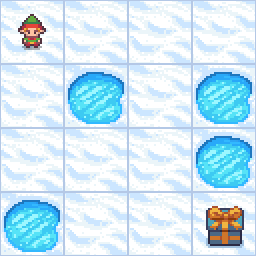

In [ ]:
video_path="replay.gif"  # Save in current directory
video_fps=1
record_video(env, Qtable_frozenlake, video_path, video_fps)

from IPython.display import Image
Image(video_path)

- https://www.youtube.com/watch?v=L-kQSpCJH4Q
- https://www.datacamp.com/tutorial/introduction-q-learning-beginner-tutorial
- https://colab.research.google.com/drive/1Ur_pYvL_IngmAttMBSZlBRwMNnpzQuY_#scrollTo=jNxUbPMP0akP